In [1]:
"""
NMF 결과 시각화 및 문서 유사도 분석 함수
"""

import os, glob, re
import sys

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.decomposition import NMF

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pycaret.clustering import setup, create_model, assign_model

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
import warnings

warnings.filterwarnings("ignore")

from utils import preprocessing


# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
def train_sklearn_nmf(documents, n_topics=5, random_state=42):
    """
    Scikit-learn을 이용한 NMF 모델 학습

    Parameters:
    -----------
    documents : list of str
        전처리된 문서 리스트

    Returns:
    --------
    nmf_model : sklearn.decomposition.NMF
        학습된 NMF 모델
    vectorizer : TfidfVectorizer
        벡터라이저
    dtm : sparse matrix
        TF-IDF 문서-단어 행렬
    """

    # NMF는 TF-IDF를 사용하는 것이 성능이 좋음
    vectorizer = TfidfVectorizer(
        max_df=0.8,
        min_df=2,
        stop_words="english",
        lowercase=True,
        token_pattern="[a-zA-Z\-][a-zA-Z\-]{2,}"
    )

    dtm = vectorizer.fit_transform(documents)

    nmf_model = NMF(
        n_components=n_topics,
        random_state=random_state,
        max_iter=500,
        init='nndsvd'
    )
    
    nmf_model.fit(dtm)
    print(f"NMF Reconstruction Error: {nmf_model.reconstruction_err_:.4f}")


    return nmf_model, vectorizer, dtm

def get_document_topics_sklearn(nmf_model, dtm):
    """
    각 문서의 토픽 분포 추출 (Scikit-learn)

    Returns:
    --------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포 행렬 (n_documents x n_topics)
    """
    doc_topic_dist = nmf_model.transform(dtm)
    return doc_topic_dist


# ==========================================
# 결과 시각화 및 분석
# ==========================================


def display_topics(model, feature_names=None, n_top_words=10, model_type="sklearn"):
    """
    각 토픽의 주요 단어 출력

    Parameters:
    -----------
    model : NMF model
        학습된 NMF 모델
    feature_names : list
        단어 리스트 (sklearn의 경우)
    n_top_words : int
        출력할 단어 개수
    model_type : str
        'gensim' 또는 'sklearn'
    """
    print(f"\n{'='*60}")
    print(f"주요 토픽 및 키워드 ({model_type.upper()})")
    print(f"{'='*60}\n")

    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"토픽 {topic_idx + 1}:")
        print(f"  {', '.join(top_words)}\n")

In [3]:
document_df = preprocessing.get_default_data()

📂 51개 파일 발견
🔄 텍스트 전처리 시작...
   옵션: HTML제거=True, URL제거=True, 숫자제거=True
   옵션: 불용어제거=True, Lemmatization=True, Stemming=False
✅ 전처리 완료:
   - 원본 문서 수: 51
   - 제거된 빈 문서: 0
   - 최종 문서 수: 51
   - 평균 단어 수: 1267.3


In [4]:
print("=" * 60)
print("NMF 토픽 모델링 시작")
print("=" * 60)

print("\n[방법 2] Scikit-learn을 이용한 NMF\n")

sklearn_model, vectorizer, dtm = train_sklearn_nmf(document_df["processed_text"])
doc_topics_sklearn = get_document_topics_sklearn(sklearn_model, dtm)

feature_names = vectorizer.get_feature_names_out()
display_topics(sklearn_model, feature_names, model_type="sklearn", n_top_words=5)

print("\n문서-토픽 분포 (첫 10개 문서):")
print(doc_topics_sklearn[:10])

NMF 토픽 모델링 시작

[방법 2] Scikit-learn을 이용한 NMF

NMF Reconstruction Error: 5.8484

주요 토픽 및 키워드 (SKLEARN)

토픽 1:
  room, hotel, clean, bathroom, staff

토픽 2:
  screen, keyboard, size, direction, speed

토픽 3:
  interior, seat, comfortable, mileage, gas

토픽 4:
  battery, life, performance, ipod, keyboard

토픽 5:
  service, food, hotel, location, staff


문서-토픽 분포 (첫 10개 문서):
[[0.00000000e+00 1.57894860e-01 1.11993345e-02 0.00000000e+00
  1.61314799e-02]
 [3.70702985e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 8.06196529e-01
  4.35181856e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 8.10280802e-01
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 8.42725708e-01
  0.00000000e+00]
 [1.58693883e-03 1.75135776e-01 2.03251419e-03 9.89109378e-03
  1.59479905e-03]
 [2.29957778e-02 0.00000000e+00 6.43208687e-01 0.00000000e+00
  0.00000000e+00]
 [4.89906586e-02 0.00000000e+00 6.39745541e-01 0.00000000e+00
  0.00000

In [5]:
def perform_advanced_pycaret_clustering(doc_topic_dist, documents=None):
    """
    고급 PyCaret 클러스터링 - 여러 알고리즘 비교 및 최적화

    Parameters:
    -----------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포
    documents : list of str
        원본 문서

    Returns:
    --------
    results : dict
        각 모델별 결과
    """
    print("\n" + "=" * 60)
    print("고급 클러스터링 분석 - 여러 알고리즘 비교")
    print("=" * 60 + "\n")

    # DataFrame 생성
    topic_columns = [f"Topic_{i+1}" for i in range(doc_topic_dist.shape[1])]
    df = pd.DataFrame(doc_topic_dist, columns=topic_columns)
    df["Document_ID"] = range(len(df))

    # PyCaret setup
    cluster_setup = setup(
        data=df,
        session_id=42,
        normalize=True,
        transformation=False,
        ignore_features=["Document_ID"],
        verbose=False,
        html=False,
    )

    # 다양한 클러스터링 알고리즘 테스트
    algorithms = ["kmeans", "ap", "meanshift", "sc", "hclust", "dbscan"]
    results = {}

    print("다양한 클러스터링 알고리즘 테스트 중...\n")

    for algo in algorithms:
        try:
            print(f"Testing {algo.upper()}...")

            # 모델 생성
            if algo in ["kmeans", "sc", "hclust"]:
                model = create_model(algo, num_clusters=3)
            else:
                model = create_model(algo)

            # 예측
            predictions = assign_model(model)
            cluster_labels = predictions["Cluster"].values

            # 평가
            from sklearn.metrics import silhouette_score, davies_bouldin_score

            silhouette = silhouette_score(doc_topic_dist, cluster_labels)
            davies_bouldin = davies_bouldin_score(doc_topic_dist, cluster_labels)
            n_clusters = len(np.unique(cluster_labels))

            results[algo] = {
                "model": model,
                "predictions": predictions,
                "silhouette_score": silhouette,
                "davies_bouldin_score": davies_bouldin,
                "n_clusters": n_clusters,
            }

            print(
                f"  ✓ Clusters: {n_clusters}, Silhouette: {silhouette:.4f}, "
                f"Davies-Bouldin: {davies_bouldin:.4f}\n"
            )

        except Exception as e:
            print(f"  ✗ {algo} 실패: {str(e)[:50]}\n")
            continue

    # 결과 요약
    print("\n" + "=" * 60)
    print("알고리즘별 성능 비교 요약")
    print("=" * 60 + "\n")

    # 결과를 DataFrame으로 정리
    summary_data = []
    for algo, result in results.items():
        summary_data.append(
            {
                "Algorithm": algo.upper(),
                "N_Clusters": result["n_clusters"],
                "Silhouette": result["silhouette_score"],
                "Davies_Bouldin": result["davies_bouldin_score"],
            }
        )

    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values("Silhouette", ascending=False)
    print(summary_df.to_string(index=False))

    # 최고 성능 모델 선택 (Silhouette 기준)
    best_algo = summary_df.iloc[0]["Algorithm"].lower()
    best_model_result = results[best_algo]

    print(f"\n최고 성능 알고리즘: {best_algo.upper()}")
    print(f"  Silhouette Score: {best_model_result['silhouette_score']:.4f}")
    print(f"  클러스터 개수: {best_model_result['n_clusters']}")

    return results, best_algo, best_model_result

In [6]:
results, best_algo, best_model_result = perform_advanced_pycaret_clustering(
    doc_topics_sklearn, document_df["opinion_text"]
)


고급 클러스터링 분석 - 여러 알고리즘 비교

다양한 클러스터링 알고리즘 테스트 중...

Testing KMEANS...


   Silhouette  Calinski-Harabasz  Davies-Bouldin  Homogeneity  Rand Index  \
0      0.3398            16.6383           1.121            0           0   

   Completeness  
0             0  


  ✓ Clusters: 3, Silhouette: 0.3228, Davies-Bouldin: 1.1627

Testing AP...


   Silhouette  Calinski-Harabasz  Davies-Bouldin  Homogeneity  Rand Index  \
0       0.605            78.5107          0.4677            0           0   

   Completeness  
0             0  


  ✓ Clusters: 7, Silhouette: 0.6018, Davies-Bouldin: 0.4674

Testing MEANSHIFT...


...

  ✓ Clusters: 3, Silhouette: 0.4316, Davies-Bouldin: 0.5840

Testing HCLUST...


   Silhouette  Calinski-Harabasz  Davies-Bouldin  Homogeneity  Rand Index  \
0      0.4224            20.7869          1.0209            0           0   

   Completeness  
0             0  


  ✓ Clusters: 3, Silhouette: 0.4258, Davies-Bouldin: 1.0347

Testing DBSCAN...


   Silhouette  Calinski-Harabasz  Davies-Bouldin  Homogeneity  Rand Index  \
0      0.1147             3.3278          2.0962            0           0   

   Completeness  
0             0  


  ✓ Clusters: 3, Silhouette: 0.1193, Davies-Bouldin: 2.0779


알고리즘별 성능 비교 요약

Algorithm  N_Clusters  Silhouette  Davies_Bouldin
       AP           7    0.601842        0.467360
MEANSHIFT           4    0.489135        0.654594
       SC           3    0.431648        0.583959
   HCLUST           3    0.425782        1.034672
   KMEANS           3    0.322797        1.162713
   DBSCAN           3    0.119329        2.077874

최고 성능 알고리즘: AP
  Silhouette Score: 0.6018
  클러스터 개수: 7


In [7]:
# best_df = pd.DataFrame(best_model_result, index=[0])
# best_df
cluster_labels = best_model_result["predictions"]["Cluster"]

In [8]:
# ==========================================
# 1. 토픽 분포 시각화
# ==========================================


def visualize_topic_distribution(doc_topic_dist, top_n=20, figsize=(12, 6)):
    """
    문서별 토픽 분포를 히트맵으로 시각화

    Parameters:
    -----------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포 행렬
    top_n : int
        표시할 상위 문서 개수
    figsize : tuple
        그래프 크기
    """
    plt.figure(figsize=figsize)

    # 상위 N개 문서만 선택
    data_subset = doc_topic_dist[:top_n]

    # 히트맵 생성
    sns.heatmap(
        data_subset,
        cmap="YlOrRd",
        annot=True,
        fmt=".2f",
        xticklabels=[f"Topic {i+1}" for i in range(doc_topic_dist.shape[1])],
        yticklabels=[f"Doc {i+1}" for i in range(top_n)],
        cbar_kws={"label": "Probability"},
    )

    plt.title("Document-Topic Distribution Heatmap", fontsize=14, fontweight="bold")
    plt.xlabel("Topics", fontsize=12)
    plt.ylabel("Documents", fontsize=12)
    plt.tight_layout()
    plt.show()


def visualize_topic_weights(doc_topic_dist, figsize=(10, 6)):
    """
    각 토픽의 전체 가중치 분포를 막대 그래프로 시각화

    Parameters:
    -----------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포 행렬
    figsize : tuple
        그래프 크기
    """
    # 각 토픽의 평균 확률 계산
    topic_weights = doc_topic_dist.mean(axis=0)

    plt.figure(figsize=figsize)

    topics = [f"Topic {i+1}" for i in range(len(topic_weights))]
    colors = plt.cm.viridis(np.linspace(0, 1, len(topics)))

    bars = plt.bar(
        topics, topic_weights, color=colors, edgecolor="black", linewidth=1.2
    )

    # 막대 위에 값 표시
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    plt.title(
        "Average Topic Weights Across All Documents", fontsize=14, fontweight="bold"
    )
    plt.xlabel("Topics", fontsize=12)
    plt.ylabel("Average Probability", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()


def visualize_dominant_topics(doc_topic_dist, figsize=(10, 6)):
    """
    각 문서의 지배적 토픽 분포를 파이 차트로 시각화

    Parameters:
    -----------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포 행렬
    figsize : tuple
        그래프 크기
    """
    # 각 문서의 지배적 토픽 찾기
    dominant_topics = np.argmax(doc_topic_dist, axis=1)

    # 토픽별 문서 개수 계산
    unique_topics, counts = np.unique(dominant_topics, return_counts=True)

    plt.figure(figsize=figsize)

    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_topics)))
    labels = [f"Topic {i+1}" for i in unique_topics]

    # 파이 차트와 함께 개수 표시
    wedges, texts, autotexts = plt.pie(
        counts,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 11, "weight": "bold"},
    )

    # 중앙에 총 문서 수 표시
    plt.text(
        0,
        0,
        f"Total\n{len(doc_topic_dist)}",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
    )

    plt.title("Distribution of Dominant Topics", fontsize=14, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()


# ==========================================
# 2. 차원 축소 시각화 (PCA, t-SNE)
# ==========================================


def visualize_topics_pca(doc_topic_dist, cluster_labels=None, figsize=(12, 8)):
    """
    PCA를 이용한 2D 토픽 공간 시각화

    Parameters:
    -----------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포 행렬
    cluster_labels : numpy.ndarray (optional)
        클러스터 레이블
    figsize : tuple
        그래프 크기
    """
    # PCA로 2차원 축소
    pca = PCA(n_components=2, random_state=23)
    coords_2d = pca.fit_transform(doc_topic_dist)

    plt.figure(figsize=figsize)

    if cluster_labels is not None:
        # 클러스터별로 색상 구분
        unique_clusters = np.unique(cluster_labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

        for i, cluster in enumerate(unique_clusters):
            mask = cluster_labels == cluster
            plt.scatter(
                coords_2d[mask, 0],
                coords_2d[mask, 1],
                c=[colors[i]],
                label=f"Cluster {cluster}",
                s=100,
                alpha=0.7,
                edgecolors="black",
                linewidth=0.5,
            )
        plt.legend(fontsize=10)
    else:
        # 지배적 토픽별로 색상 구분
        dominant_topics = np.argmax(doc_topic_dist, axis=1)
        scatter = plt.scatter(
            coords_2d[:, 0],
            coords_2d[:, 1],
            c=dominant_topics,
            cmap="tab10",
            s=100,
            alpha=0.7,
            edgecolors="black",
            linewidth=0.5,
        )
        cbar = plt.colorbar(scatter)
        cbar.set_label("Dominant Topic", fontsize=11)

    plt.title("PCA: Document-Topic Space (2D)", fontsize=14, fontweight="bold")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)", fontsize=12)
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)", fontsize=12)
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

    print(f"총 설명된 분산: {pca.explained_variance_ratio_.sum():.2%}")


def visualize_topics_tsne(
    doc_topic_dist, cluster_labels=None, figsize=(12, 8), perplexity=30
):
    """
    t-SNE를 이용한 2D 토픽 공간 시각화

    Parameters:
    -----------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포 행렬
    cluster_labels : numpy.ndarray (optional)
        클러스터 레이블
    figsize : tuple
        그래프 크기
    perplexity : int
        t-SNE perplexity 파라미터
    """
    # t-SNE로 2차원 축소
    tsne = TSNE(n_components=2, random_state=23, perplexity=perplexity)
    coords_2d = tsne.fit_transform(doc_topic_dist)

    plt.figure(figsize=figsize)

    if cluster_labels is not None:
        # 클러스터별로 색상 구분
        unique_clusters = np.unique(cluster_labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

        for i, cluster in enumerate(unique_clusters):
            mask = cluster_labels == cluster
            plt.scatter(
                coords_2d[mask, 0],
                coords_2d[mask, 1],
                c=[colors[i]],
                label=f"Cluster {cluster}",
                s=100,
                alpha=0.7,
                edgecolors="black",
                linewidth=0.5,
            )
        plt.legend(fontsize=10)
    else:
        # 지배적 토픽별로 색상 구분
        dominant_topics = np.argmax(doc_topic_dist, axis=1)
        scatter = plt.scatter(
            coords_2d[:, 0],
            coords_2d[:, 1],
            c=dominant_topics,
            cmap="tab10",
            s=100,
            alpha=0.7,
            edgecolors="black",
            linewidth=0.5,
        )
        cbar = plt.colorbar(scatter)
        cbar.set_label("Dominant Topic", fontsize=11)

    plt.title("t-SNE: Document-Topic Space (2D)", fontsize=14, fontweight="bold")
    plt.xlabel("t-SNE Component 1", fontsize=12)
    plt.ylabel("t-SNE Component 2", fontsize=12)
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()


# ==========================================
# 3. 인터랙티브 시각화 (Plotly)
# ==========================================


def visualize_topics_interactive_3d(
    doc_topic_dist, cluster_labels=None, documents=None
):
    """
    Plotly를 이용한 인터랙티브 3D 시각화

    Parameters:
    -----------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포 행렬
    cluster_labels : numpy.ndarray (optional)
        클러스터 레이블
    documents : list of str (optional)
        원본 문서 (hover 정보용)
    """
    # PCA로 3차원 축소
    pca = PCA(n_components=3, random_state=23)
    coords_3d = pca.fit_transform(doc_topic_dist)

    # DataFrame 생성
    df_viz = pd.DataFrame(
        {
            "PC1": coords_3d[:, 0],
            "PC2": coords_3d[:, 1],
            "PC3": coords_3d[:, 2],
            "Document_ID": range(len(doc_topic_dist)),
        }
    )

    if cluster_labels is not None:
        df_viz["Cluster"] = cluster_labels.astype(str)
        color_col = "Cluster"
    else:
        dominant_topics = np.argmax(doc_topic_dist, axis=1)
        df_viz["Dominant_Topic"] = [f"Topic {i+1}" for i in dominant_topics]
        color_col = "Dominant_Topic"

    if documents is not None:
        df_viz["Document"] = [doc[:100] + "..." for doc in documents]
        hover_data = ["Document_ID", "Document"]
    else:
        hover_data = ["Document_ID"]

    # 3D 산점도
    fig = px.scatter_3d(
        df_viz,
        x="PC1",
        y="PC2",
        z="PC3",
        color=color_col,
        hover_data=hover_data,
        title="Interactive 3D Document-Topic Space (PCA)",
        labels={
            "PC1": f"PC1 ({pca.explained_variance_ratio_[0]:.2%})",
            "PC2": f"PC2 ({pca.explained_variance_ratio_[1]:.2%})",
            "PC3": f"PC3 ({pca.explained_variance_ratio_[2]:.2%})",
        },
    )

    fig.update_traces(marker=dict(size=5, line=dict(width=0.5, color="DarkSlateGrey")))
    fig.update_layout(height=700, showlegend=True)
    fig.show()


def visualize_cluster_comparison(results, metric="silhouette_score"):
    """
    여러 클러스터링 알고리즘의 성능을 비교하는 막대 그래프

    Parameters:
    -----------
    results : dict
        각 알고리즘별 결과 딕셔너리
    metric : str
        비교할 메트릭 ('silhouette_score' 또는 'davies_bouldin_score')
    """
    algorithms = []
    scores = []

    for algo, result in results.items():
        algorithms.append(algo.upper())
        scores.append(result[metric])

    # 정렬
    sorted_indices = (
        np.argsort(scores)[::-1] if metric == "silhouette_score" else np.argsort(scores)
    )
    algorithms = [algorithms[i] for i in sorted_indices]
    scores = [scores[i] for i in sorted_indices]

    # Plotly 막대 그래프
    fig = go.Figure(
        data=[
            go.Bar(
                x=algorithms,
                y=scores,
                text=[f"{s:.4f}" for s in scores],
                textposition="auto",
                marker=dict(
                    color=scores,
                    colorscale="Viridis",
                    showscale=True,
                    colorbar=dict(title=metric.replace("_", " ").title()),
                ),
            )
        ]
    )

    title = "Clustering Algorithm Comparison: " + metric.replace("_", " ").title()
    fig.update_layout(
        title=title,
        xaxis_title="Algorithm",
        yaxis_title=metric.replace("_", " ").title(),
        height=500,
        showlegend=False,
    )

    fig.show()


# ==========================================
# 4. 문서 유사도 분석
# ==========================================


def calculate_document_similarity(doc_topic_dist, method="cosine"):
    """
    문서 간 유사도 행렬 계산

    Parameters:
    -----------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포 행렬
    method : str
        유사도 계산 방법 ('cosine' 또는 'euclidean')

    Returns:
    --------
    similarity_matrix : numpy.ndarray
        유사도 행렬
    """
    if method == "cosine":
        similarity_matrix = cosine_similarity(doc_topic_dist)
    elif method == "euclidean":
        # 유클리드 거리를 유사도로 변환 (거리가 작을수록 유사도 높음)
        distances = euclidean_distances(doc_topic_dist)
        similarity_matrix = 1 / (1 + distances)
    else:
        raise ValueError("method must be 'cosine' or 'euclidean'")

    return similarity_matrix


def visualize_similarity_matrix(similarity_matrix, top_n=30, figsize=(12, 10)):
    """
    문서 유사도 행렬을 히트맵으로 시각화

    Parameters:
    -----------
    similarity_matrix : numpy.ndarray
        유사도 행렬
    top_n : int
        표시할 상위 문서 개수
    figsize : tuple
        그래프 크기
    """
    plt.figure(figsize=figsize)

    # 상위 N개 문서만 선택
    matrix_subset = similarity_matrix[:top_n, :top_n]

    # 히트맵 생성
    sns.heatmap(
        matrix_subset,
        cmap="RdYlGn",
        center=0.5,
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Similarity"},
        xticklabels=[f"D{i+1}" for i in range(top_n)],
        yticklabels=[f"D{i+1}" for i in range(top_n)],
    )

    plt.title("Document Similarity Matrix (Cosine)", fontsize=14, fontweight="bold")
    plt.xlabel("Documents", fontsize=12)
    plt.ylabel("Documents", fontsize=12)
    plt.tight_layout()
    plt.show()


def find_similar_documents(doc_id, similarity_matrix, documents=None, top_k=5):
    """
    특정 문서와 가장 유사한 문서들 찾기

    Parameters:
    -----------
    doc_id : int
        기준 문서 ID
    similarity_matrix : numpy.ndarray
        유사도 행렬
    documents : list of str (optional)
        원본 문서
    top_k : int
        반환할 유사 문서 개수

    Returns:
    --------
    similar_docs : DataFrame
        유사 문서 정보
    """
    # 자기 자신 제외
    similarities = similarity_matrix[doc_id].copy()
    similarities[doc_id] = -1

    # 상위 K개 찾기
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    results = {
        "Rank": range(1, top_k + 1),
        "Document_ID": top_indices,
        "Similarity": similarities[top_indices],
    }

    if documents is not None:
        results["Document"] = [documents[i][:100] + "..." for i in top_indices]

    similar_docs = pd.DataFrame(results)

    print(f"\n{'='*80}")
    print(f"문서 {doc_id}와 가장 유사한 문서 Top {top_k}")
    print(f"{'='*80}")
    if documents is not None:
        print(f"\n[기준 문서 {doc_id}]")
        print(documents[doc_id][:200] + "...\n")
    print(similar_docs.to_string(index=False))
    print(f"{'='*80}\n")

    return similar_docs


def analyze_cluster_similarity(doc_topic_dist, cluster_labels):
    """
    클러스터 간 유사도 분석

    Parameters:
    -----------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포 행렬
    cluster_labels : numpy.ndarray
        클러스터 레이블
    """
    unique_clusters = np.unique(cluster_labels)
    n_clusters = len(unique_clusters)

    # 클러스터 중심점 계산
    cluster_centers = np.zeros((n_clusters, doc_topic_dist.shape[1]))
    for i, cluster in enumerate(unique_clusters):
        mask = cluster_labels == cluster
        cluster_centers[i] = doc_topic_dist[mask].mean(axis=0)

    # 클러스터 간 유사도 계산
    cluster_similarity = cosine_similarity(cluster_centers)

    # 시각화
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cluster_similarity,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        center=0.5,
        square=True,
        linewidths=2,
        cbar_kws={"label": "Cosine Similarity"},
        xticklabels=[f"Cluster {c}" for c in unique_clusters],
        yticklabels=[f"Cluster {c}" for c in unique_clusters],
    )

    plt.title("Cluster-to-Cluster Similarity Matrix", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # 가장 유사한 클러스터 쌍 찾기
    # 대각선 제외
    np.fill_diagonal(cluster_similarity, -1)
    max_sim_idx = np.unravel_index(
        cluster_similarity.argmax(), cluster_similarity.shape
    )

    print(f"\n가장 유사한 클러스터 쌍:")
    print(
        f"  Cluster {unique_clusters[max_sim_idx[0]]} ↔ Cluster {unique_clusters[max_sim_idx[1]]}"
    )
    print(f"  Similarity: {cluster_similarity[max_sim_idx]:.4f}\n")


def create_similarity_report(doc_topic_dist, cluster_labels=None, documents=None):
    """
    전체 유사도 분석 리포트 생성

    Parameters:
    -----------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포 행렬
    cluster_labels : numpy.ndarray (optional)
        클러스터 레이블
    documents : list of str (optional)
        원본 문서
    """
    print("\n" + "=" * 80)
    print("문서 유사도 종합 분석 리포트")
    print("=" * 80 + "\n")

    # 1. 유사도 행렬 계산
    print("1. 코사인 유사도 행렬 계산 중...")
    similarity_matrix = calculate_document_similarity(doc_topic_dist, method="cosine")

    # 2. 기본 통계
    # 대각선 제외
    np.fill_diagonal(similarity_matrix, np.nan)

    print(f"\n유사도 통계:")
    print(f"  평균 유사도: {np.nanmean(similarity_matrix):.4f}")
    print(f"  최대 유사도: {np.nanmax(similarity_matrix):.4f}")
    print(f"  최소 유사도: {np.nanmin(similarity_matrix):.4f}")
    print(f"  표준편차: {np.nanstd(similarity_matrix):.4f}")

    # 3. 가장 유사한 문서 쌍 찾기
    max_sim_idx = np.unravel_index(
        np.nanargmax(similarity_matrix), similarity_matrix.shape
    )
    print(f"\n가장 유사한 문서 쌍:")
    print(f"  문서 {max_sim_idx[0]} ↔ 문서 {max_sim_idx[1]}")
    print(f"  유사도: {similarity_matrix[max_sim_idx]:.4f}")

    if documents is not None:
        print(f"\n  [문서 {max_sim_idx[0]}]: {documents[max_sim_idx[0]][:100]}...")
        print(f"  [문서 {max_sim_idx[1]}]: {documents[max_sim_idx[1]][:100]}...")

    # 4. 클러스터별 분석 (있는 경우)
    if cluster_labels is not None:
        print(f"\n2. 클러스터 간 유사도 분석")
        analyze_cluster_similarity(doc_topic_dist, cluster_labels)

    print("=" * 80 + "\n")

    return similarity_matrix


# ==========================================
# 5. 종합 시각화 함수
# ==========================================


def visualize_all(
    doc_topic_dist, cluster_labels=None, documents=None, results=None, top_n_docs=20
):
    """
    모든 시각화를 한 번에 실행

    Parameters:
    -----------
    doc_topic_dist : numpy.ndarray
        문서-토픽 분포 행렬
    cluster_labels : numpy.ndarray (optional)
        클러스터 레이블
    documents : list of str (optional)
        원본 문서
    results : dict (optional)
        클러스터링 알고리즘 결과
    top_n_docs : int
        히트맵에 표시할 문서 개수
    """
    print("\n" + "=" * 80)
    print("전체 시각화 생성 중...")
    print("=" * 80 + "\n")

    # 1. 토픽 분포 시각화
    print("1. 토픽 분포 히트맵")
    visualize_topic_distribution(doc_topic_dist, top_n=top_n_docs)

    print("\n2. 토픽 가중치 분포")
    visualize_topic_weights(doc_topic_dist)

    print("\n3. 지배적 토픽 분포")
    visualize_dominant_topics(doc_topic_dist)

    # 2. 차원 축소 시각화
    print("\n4. PCA 2D 시각화")
    visualize_topics_pca(doc_topic_dist, cluster_labels)

    print("\n5. t-SNE 2D 시각화")
    visualize_topics_tsne(doc_topic_dist, cluster_labels)

    # 3. 인터랙티브 시각화
    print("\n6. 인터랙티브 3D 시각화")
    visualize_topics_interactive_3d(doc_topic_dist, cluster_labels, documents)

    # 4. 클러스터링 비교 (결과가 있는 경우)
    if results is not None:
        print("\n7. 클러스터링 알고리즘 비교")
        visualize_cluster_comparison(results, metric="silhouette_score")

    # 5. 유사도 분석
    print("\n8. 문서 유사도 행렬")
    similarity_matrix = calculate_document_similarity(doc_topic_dist)
    visualize_similarity_matrix(similarity_matrix, top_n=top_n_docs)

    # 6. 종합 리포트
    print("\n9. 유사도 종합 분석")
    create_similarity_report(doc_topic_dist, cluster_labels, documents)

    print("\n" + "=" * 80)
    print("모든 시각화 완료!")
    print("=" * 80 + "\n")


시각화  실행


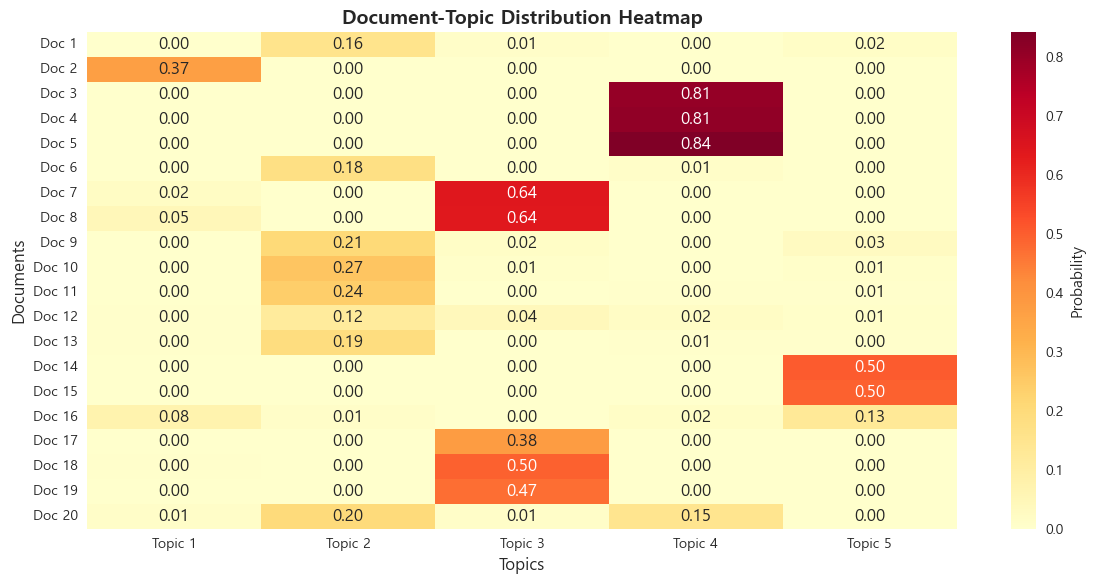

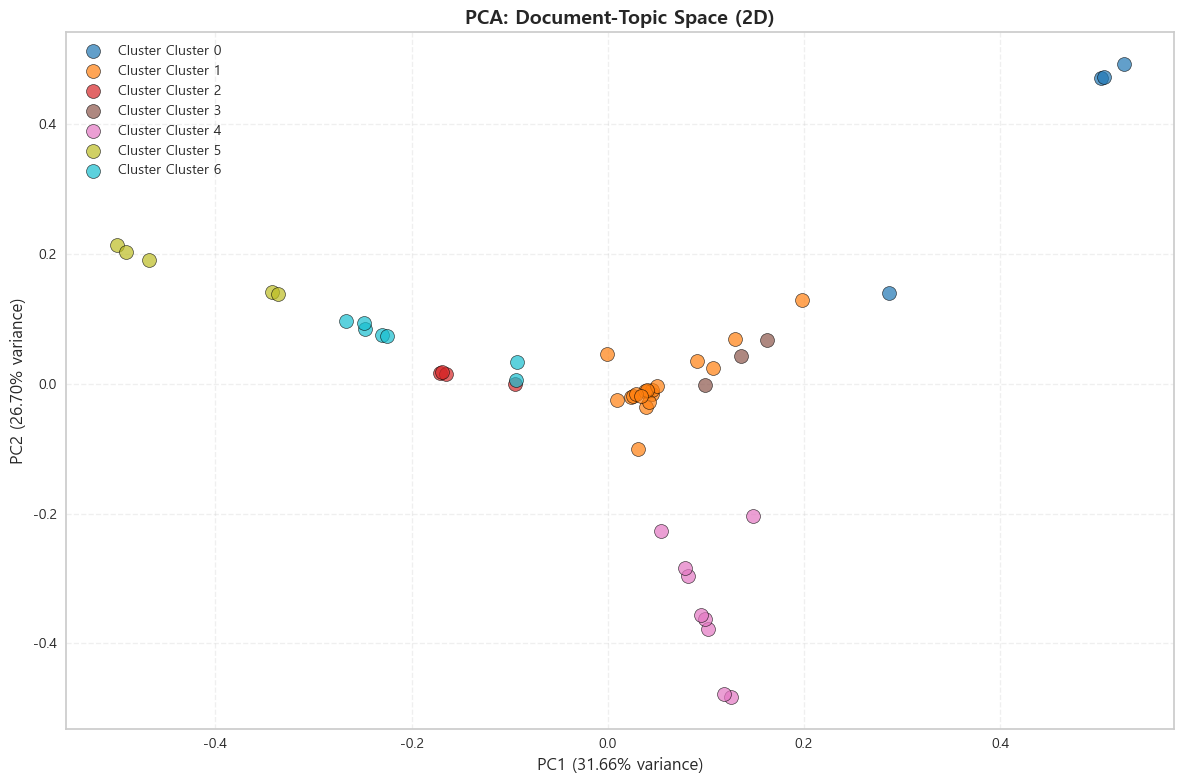

총 설명된 분산: 58.36%

문서 0와 가장 유사한 문서 Top 5

[기준 문서 0]
, and is very, very accurate .
 but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .
 This function is not accurate if you don't leave it i...

 Rank  Document_ID  Similarity                                                                                                 Document
    1            8    0.999584   You also get upscale features like spoken directions including street names and programmable POIs ....
    2           50    0.997377   The voice prompts and maps are wonderful especially when driving after dark .\nI also thought the t...
    3            9    0.997144 3 quot  widescreen display was a bonus .\n This made for smoother graphics on the 255w of the vehicle...
    4           43    0.996952  Another feature on the 255w is a display of the posted speed limit on the road which you are current...
    5           48    0.995573  Another thing to consider was th

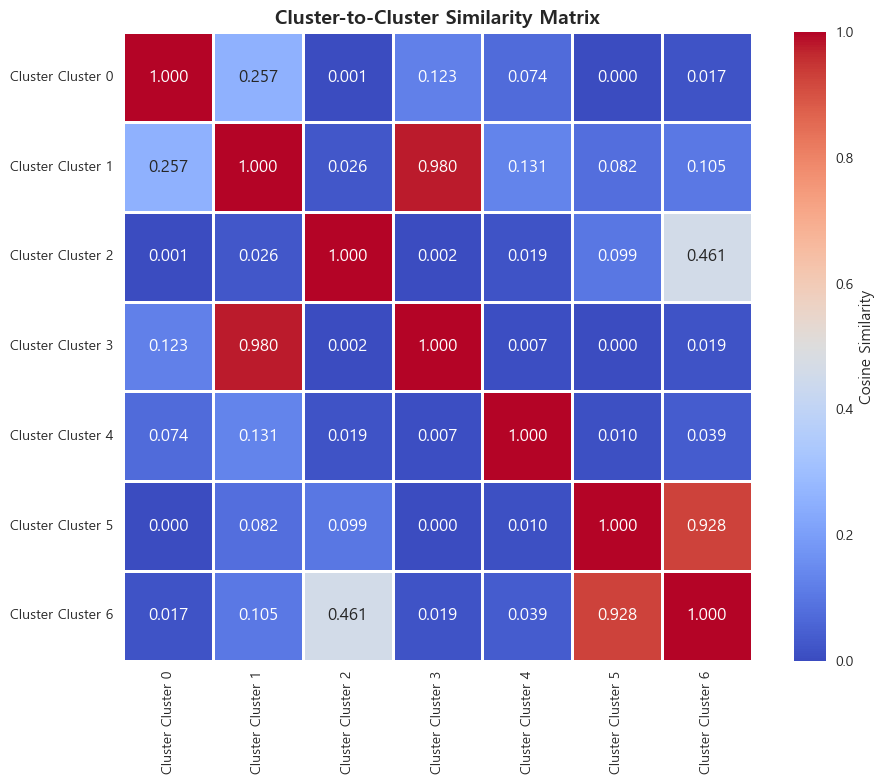


가장 유사한 클러스터 쌍:
  Cluster Cluster 1 ↔ Cluster Cluster 3
  Similarity: 0.9804



In [9]:
# ==========================================
# 사용
# ==========================================

if __name__ == "__main__":

    print("\n시각화  실행")
    print("=" * 80)

    # 개별 시각화 실행
    visualize_topic_distribution(doc_topics_sklearn, top_n=20)
    visualize_topics_pca(doc_topics_sklearn, cluster_labels)

    # 유사도 분석
    similarity_matrix = calculate_document_similarity(doc_topics_sklearn)
    find_similar_documents(0, similarity_matrix, document_df["opinion_text"], top_k=5)
    analyze_cluster_similarity(doc_topics_sklearn, cluster_labels)
    # 전체 시각화 (주석 처리 - 필요시 활성화)
    # visualize_all(doc_topics_sklearn,cluster_labels,document_df["opinion_text"],results=results)